<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-15/KNNCensus0611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Carregamento de Dados | KNN Base [Fase 1 - census_data]

## Importar dados do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

# Pipeline KNN | KNN Base [Fase 2 - census_data]

## Treinamento do KNN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn_census_data = KNeighborsClassifier(

    n_neighbors=5,

    metric='minkowski',

    p=2
)

knn_census_data.fit(
    X_census_treinamento,
    Y_census_treinamento
)

KNeighborsClassifier()

In [10]:
modelo = KNeighborsClassifier(

    n_neighbors=5,             # quantidade de vizinhos analisados

    metric='minkowski',        # metrica de distancia utilizada

    p=2,                       # p=2 -> distancia euclidiana, p=1 -> manhattan

    weights='uniform',         # peso dos vizinhos (uniform ou distance)

    algorithm='auto',          # algoritmo de busca dos vizinhos

    n_jobs=-1                  # utiliza todos os nucleos do processador
)

# Pipeline Medicoes Harmonicas | KNN Base [Fase 3 - census_data]

## Avaliacao do KNN

In [11]:
previsoes_knn = knn_census_data.predict(X_census_teste)

In [12]:
previsoes_knn

array([' <=50K', ' <=50K', ' >50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [13]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
accuracy_score(Y_census_teste, previsoes_knn)

0.8223132036847492

In [16]:
from yellowbrick.classifier import ConfusionMatrix

In [17]:
print(classification_report(Y_census_teste, previsoes_knn))

              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.88      3693
        >50K       0.66      0.57      0.61      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.74      0.75      4885
weighted avg       0.82      0.82      0.82      4885



0.8223132036847492

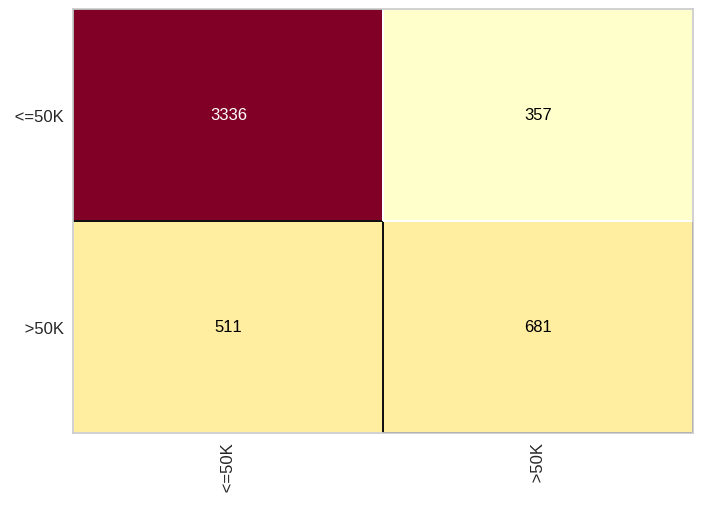

In [18]:
cm_census_knn = ConfusionMatrix(knn_census_data)
cm_census_knn.fit(X_census_treinamento, Y_census_treinamento)
cm_census_knn.score(X_census_teste, Y_census_teste)